## Options pricing

We will start by considering 2 types of options, European call options and European put options.

The European call option grants the holder the right to buy an asset at a fixed "strike price" K at a fixed date, no matter the market value at that time. The payoff at time T (expiry) can be defined as the difference between the current price $S_T$ and the strike price, or 0 if ths value is negative. The zero comes from the fact that one is not obligated to excercize their option. $$C_T = max(S_T - K, 0)$$

The European put option works similarly, granting the holder the right to sell an asset at the strike price at expiry. $$P_T = max(K - S_T, 0)$$

The fair price for an option at teh time of purchase, is the expected payoff, discounted under the risk neutral measure $\mathbb{Q}$.

$$C_0 = e^{-rT} \mathbb{E}^{\mathbb{Q}}[\max(S_T - K, 0)]$$

r is the risk free rate, the rate of interest of a risk-free investment such as US treasury bills. Under the risk neutral measure, the drift $\mu$ is replaced by r, ensuring there is no possibility of arbitrage.

## Black-Scholes

If we assume that the underlying assets price follows GBM with a constant volitility, we can find a closed form solution to this equation

$$C_0 = S_0 N(d_1) - K e^{-rT} N(d_2)$$

$$P_0 = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

where

$$d_1 = \frac{\ln\left(\frac{S_0}{K}\right) + \left(r + \frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - \sigma\sqrt{T}$$

And $N(x)$ is the cumulative standard normal distribution function. 
$N(d_2)$ represents the risk neutral probability the option expires in the 
money, while $N(d_1)$ is the option's "Delta", its sensitivity to the 
underlying asset price.

## Monte Carlo Pricing

Instead of solving the equation analytically, we can just simulate the asset price under many paths under the risk neutral measure and take the average of the discounted payoffs.

$$C_0 \approx e^{-rT} \frac{1}{I}\sum_{i=1}^{I} \max(S_T^{(i)} - K, 0)$$

As we increase I (number of paths), $C_0$ converges to the true price. For the GBM constant volitlity assumption, Monte Carlo is less efficient than Black-Scholes, however, we can run Monte Carlo for any model as well as any options type, making at significantly more veratile.

When running Monte Carlo pricing with the Heston model, the asset end price distribution should have fatter tails, meaning it should price out of the money options (options that would draw a loss if excercised immediately at purchase) higher than Balck-Scholes, with its constant volitlity assumption.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
from utils import gbm_simulate, hest_simulate

In [10]:
# price parameters
S0    = 100    # initial price
mu = 0.05 # drift for GBM
r    = 0.05   # annual return/drift
T     = 1.0    # time horizon
N     = int(252 * T)    # time steps (number of trading days)
I     = 10     # number of simulated paths


# volitility parameters
v0    = 0.04    # initial variance (sigma = 0.20)
kappa = 2.0     # speed of mean reversion
theta = 0.2272**2    # Average variance (σ = 0.20)
xi    = 0.3     # volatility of volatility
rho   = -0.7    # correlation between the two brownian motions
sigma = 0.20 # gbm volitility

# options parameters
K = 105 # strike price

np.random.seed(537418204)

feller = 2 * kappa * theta
print(f"Feller condition : 2*kappa*theta = {feller:.4f}, xi^2 = {xi**2:.4f}")
print(f"Feller satisfied : {feller > xi**2}")

Feller condition : 2*kappa*theta = 0.2065, xi^2 = 0.0900
Feller satisfied : True


GBM Monte Carlo pricing

In [11]:

S_gbm, times = gbm_simulate(S0, mu, sigma, T, N, I)

call_pay_gbm = np.maximum(S_gbm[-1] - K,0)
put_pay_gbm = np.maximum(K - S_gbm[-1], 0)

call_price_gbm = np.exp(-r*T)*call_pay_gbm.mean()
put_price_gbm = np.exp(-r*T)*put_pay_gbm.mean()

print(f"Asset mean : ${S_gbm[-1].mean():.4f}")
print(f"GBM Monte Carlo Call (K = 105) : ${call_price_gbm:.4f}")
print(f"GBM Monte Carlo Put (K = 105) : ${put_price_gbm:.4f}")

Asset mean : $107.9244
GBM Monte Carlo Call (K = 105) : $7.2158
GBM Monte Carlo Put (K = 105) : $4.4341


Heston Monte Carlo pricing

In [12]:
S_hest, v, times= hest_simulate(S0, mu, v0, kappa, theta, xi, rho, T, N, I)

call_pay_hest = np.maximum(S_hest[-1] - K,0)
put_pay_hest = np.maximum(K - S_hest[-1], 0)

call_price_hest = np.exp(-r*T)*call_pay_hest.mean()
put_price_hest = np.exp(-r*T)*put_pay_hest.mean()

print(f"Asset mean : ${S_hest[-1].mean():.4f}")
print(f"GBM Monte Carlo Call (K = 105) : ${call_price_hest:.4f}")
print(f"GBM Monte Carlo Put (K = 105) : ${put_price_hest:.4f}")

Asset mean : $119.2413
GBM Monte Carlo Call (K = 105) : $17.5237
GBM Monte Carlo Put (K = 105) : $3.9770


Black_Scholes pricing

In [13]:
def black_scholes(S0, K, r, sigma, T, option_type='call'):

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S0 * stats.norm.cdf(d1) - K*np.exp(-r*T)*stats.norm.cdf(d2)
    elif option_type == 'put':
        price = K*np.exp(-r*T)*stats.norm.cdf(-d2) - S0 * stats.norm.cdf(-d1)

    return price

In [14]:

bs_call = black_scholes(S0, K, r, sigma, T, 'call')
bs_put = black_scholes(S0, K, r, sigma, T, 'put')

print(f"{'':20} {'Call':>12} {'Put':>12}")
print(f"{'Black-Scholes':20} {bs_call:>12.4f} {bs_put:>12.4f}")
print(f"{'GBM Monte Carlo':20} {call_price_gbm:>12.4f} {put_price_gbm:>12.4f}")
print(f"{'Heston Monte Carlo':20} {call_price_hest:>12.4f} {put_price_hest:>12.4f}")
print(f"{'GBM Error':20} {abs(bs_call - call_price_gbm):>12.4f} {abs(bs_put - put_price_gbm):>12.4f}")
print(f"{'Heston Difference':20} {abs(bs_call - call_price_hest):>12.4f} {abs(bs_put - put_price_hest):>12.4f}")

                             Call          Put
Black-Scholes              8.0214       7.9004
GBM Monte Carlo            7.2158       4.4341
Heston Monte Carlo        17.5237       3.9770
GBM Error                  0.8055       3.4664
Heston Difference          9.5023       3.9235


## Evaluation

Black-Scholes and Monte Carlo GBM return very similar results, validation the simulation.
As predicted, for the OTM calls, Heston prices are much higher. The prices form the ITM puts is also higher with heston but not as dramatically. This is due to the negative correlation $\rho$ = -0.7 in Heston creating a leftwards skew on asset price relative to GBM.


# Implied Volitlity

Volitility is an input in Black-Scholes, so, we can take options pricing and reverse black scholes to get the "implied volitlity" of the option. We done have a closed form inverse of Black-Scholes so we make an "objective function" $$f(\sigma) = C_{BS}(\sigma) - C^{market}_0$$

and find the root to get the value of sigma where Black-Scholes price is equal to market price.

In [15]:
def implied_vol(price, S0, K, r, T, option_type):
    def objective(sigma):
        return black_scholes(S0, K, r, sigma, T, option_type) - price
    try:
        return brentq(objective, 1e-6, 10.0)
    except:
        return np.nan

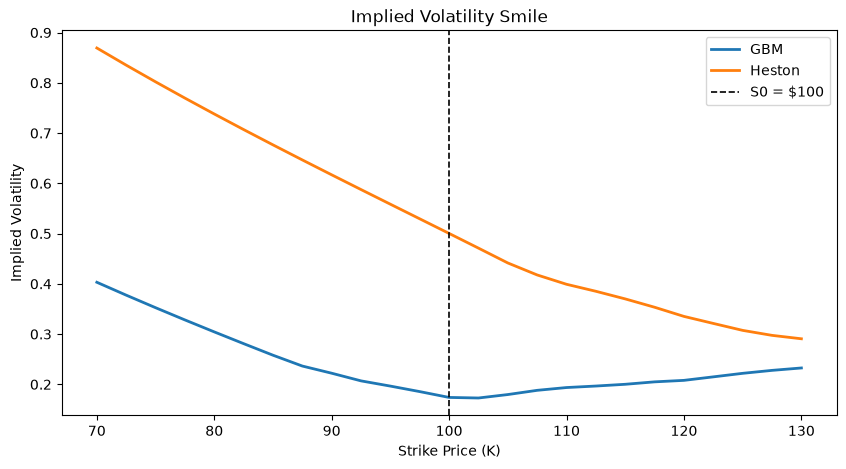

In [16]:

strikes = np.linspace(70, 130, 25)

iv_gbm  = []
iv_hest = []

for K_i in strikes:

    price_gbm  = np.exp(-r * T) * np.maximum(S_gbm[-1]  - K_i, 0).mean()
    price_hest = np.exp(-r * T) * np.maximum(S_hest[-1] - K_i, 0).mean()

    iv_gbm.append(implied_vol(price_gbm,  S0, K_i, r, T, 'call'))
    iv_hest.append(implied_vol(price_hest, S0, K_i, r, T, 'call'))

iv_gbm  = np.array(iv_gbm)
iv_hest = np.array(iv_hest)


plt.figure(figsize=(10, 5))
plt.plot(strikes, iv_gbm,  lw=2, label='GBM')
plt.plot(strikes, iv_hest, lw=2, label='Heston')
plt.axvline(S0, color='black', linestyle='--', lw=1.2, label=f'S0 = ${S0}')
plt.title("Implied Volatility Smile")
plt.xlabel("Strike Price (K)")
plt.ylabel("Implied Volatility")
plt.legend()
plt.show()

## Evaluation

The GBM line is flat as Monte Carlo on the GBM model is the same as Black-Scholes, so we are just taking a function then inverting it. Heston slopes down due to our correlation of $\rho$ = -0.7. Extreme moves downwards are more likely than extreme moves upwards. This is what we do see in real equity markets and is the reason we have set this value of $\rho$ adn why the Heston model options prices are superior to Black-Scholes pricing.